# **PARTE PREVIA**

A continuación realizaremos un estudio sobre los 6 datasets subidos para realizar el trabajo práctico (en adelante TP). Esto será compartido con todo el equipo.

Empezaremos por un análisis previo con el claro objetivo de ver que datasets elegimos para realizar el TP.

**INFORMACIÓN SOBRE LOS DATOS**

*  C. elegans: Una red dirigida y pesada que representa la red de conexiones neuronales en el organismo Caenorhabditis elegans (un nematodo). Cada nodo es una neurona, y cada enlace una conexión entre neuronas. El sistema nervioso de este organismo es el único al cual se le han podido reconstruir todas sus conexiones neuronales. Además, en este dataset también se indica si la conexión sináptica es excitatoria (’exc’) o inhibitoria  (’inh’), así como el peso de la conexión. Contiene 299 nodos y 2279 enlances.

*  Facebook: Una red no dirigida y no pesada de círculos de Facebook. Los datos fueron regoidos por una encuesta realizada en la app de Facebook. Cada nodo es un perfil de Facebook y un enlace significa que los perfiles son amigos en Facebook. Contiene 4039 nodos y 88234 enlaces.

*  **Email-EU**: Una red no dirigida y no pesada de contactos vía e-mail en una institución europea de investigación. Cada nodo es una persona dentro de la institución, un enlace significa que estas personas intercambiaron al menos un email. Para este dataset también tenemos un label conocido de antemano para cada nodo, que representa a qué departamento de la institución pertenece el nodo. Contiene 1005 nodos y 25571 enlaces.

*  Aeropuertos: Una red dirigida y pesada. Cada nodo es un aeropuerto de Estados Unidos, y los enlaces representan vuelos realizados en el año 2025. El peso de cada enlace indica el número total de vuelos de dicha ruta. Hay información sobre las coordenadas espaciales de cada aeropuerto. Contiene 1252 nodos y 23092 enlaces.

*  CONICET: Una red no dirigida y no pesada. Cada nodo es un autor de un subconjunto de la base de datos del CONICET para las publicaciones entre 2023 y 2024.
Tiene metadatos de los autores con sus áreas de investigación. Tiene 8288 nodos y 14105 enlaces.

*  Bariloche: Una red dirigida y pesada construida a partir de la información disponible en OpenStreetMap (vía el paquete osmnx). Cada nodo es una intersección y cada enlace una vía manejable. Contiene metadatos adicionales con la ubicación, tipo de vía y velocidad máxima, entre otros. Tiene 4905 nodos y 13582 enlaces.

**SET DE INDICADORES PARA REALIZAR EL ANÁLISIS E INSPECCIÓN DE LOS DATASETS PREVIA ELECCIÓN**

*  Características de las redes: es dirigído?, es pesado? es conectado? es fuertemente conexo? es debilmente conexo?
*  Análisis de componente gigante: borrando autoenlaces, analizamos su conexión
*  Realizamos una visualización espacial de cada nodo si existe información sobre posición.
*  Grados de nodo
*  Coeficiente de clustering
*  Coeficiente de transitividad
*  Coeficiente de asortatividad
*  Distancias mínimas medias

In [1]:
import matplotlib.pyplot as plt
import os

# Números y Datos
import numpy as np
import networkx as nx
from networkx.algorithms.approximation import average_clustering
import community.community_louvain as cl

import pandas as pd
import pickle

In [2]:
# DATOS REDES:
!wget -O datasets-tp1.zip https://www.dropbox.com/scl/fi/ke7kyfox7w6hnmcnt3x2b/datasets-tp1.zip?rlkey=m7uljexxrljs6bu9pcv8qtyh7&st=09rgvayp&dl=1
!unzip -o datasets-tp1.zip

--2026-04-26 11:54:54--  https://www.dropbox.com/scl/fi/ke7kyfox7w6hnmcnt3x2b/datasets-tp1.zip?rlkey=m7uljexxrljs6bu9pcv8qtyh7
Resolving www.dropbox.com (www.dropbox.com)... 162.125.65.18, 2620:100:6021:18::a27d:4112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.65.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc531ed809304278a50c22d9c507.dl.dropboxusercontent.com/cd/0/inline/C_WjXlf1RgCyzKt-cSzFrl3oAGHQTqA4TBHwVlMNSNNNx097nour5o9HdqghJVsFgx94rRGxofdZyxeFkbqk53FAmRuKaNLeAXoMLBzHv7J78UBfps_5sq_y6C2yGGi6215ZkprF5dfVOTE88v8fFfNc/file# [following]
--2026-04-26 11:54:55--  https://uc531ed809304278a50c22d9c507.dl.dropboxusercontent.com/cd/0/inline/C_WjXlf1RgCyzKt-cSzFrl3oAGHQTqA4TBHwVlMNSNNNx097nour5o9HdqghJVsFgx94rRGxofdZyxeFkbqk53FAmRuKaNLeAXoMLBzHv7J78UBfps_5sq_y6C2yGGi6215ZkprF5dfVOTE88v8fFfNc/file
Resolving uc531ed809304278a50c22d9c507.dl.dropboxusercontent.com (uc531ed809304278a50c22d9c507.dl.dropboxusercontent.com)... 162.125.65.15

In [3]:
import pandas as pd
import networkx as nx

# =========================
# 1. Cargar aristas
# =========================

def read_graph(filename):
    G = nx.Graph()
    array = np.loadtxt(filename, dtype=int)
    G.add_edges_from(array)
    return G

G = read_graph('email-Eu-core.txt')

In [4]:
G.number_of_nodes()

1005

## Diagnostico
- Dirigido
- Pesado
- Conectividad

In [5]:
def diagnostico_grafo(G, nombre):
    print(f"--- Diagnóstico: {nombre} ---")
    print(G)

    # 1. Dirección
    dirigido = nx.is_directed(G)
    print(f'¿Es dirigido?: {dirigido}')

    # 2. Peso (adaptado a tu dataset)
    es_pesado = any('PASSENGERS' in data for u, v, data in G.edges(data=True))
    print(f'¿Es pesado?: {es_pesado}')

    # 3. Conectividad
    if dirigido:
        conexo_debil = nx.is_weakly_connected(G)
        conexo_fuerte = nx.is_strongly_connected(G)
        print(f'¿Es conexo (débil)?: {conexo_debil}')
        print(f'¿Es conexo (fuerte)?: {conexo_fuerte}')
    else:
        conexo = nx.is_connected(G)
        print(f'¿Es conectado?: {conexo}')

    print('\n')

# Ejecutar
diagnostico_grafo(G, "Email")

--- Diagnóstico: Email ---
Graph with 1005 nodes and 16706 edges
¿Es dirigido?: False
¿Es pesado?: False
¿Es conectado?: False




comentarios..............

## **PARA EL GRAFO COMPLETO**
Nodos: 1005\
Aristas: 16706\
Grado promedio (total): 33.245771144278606\
Clustering (sobre versión no dirigida): 0.3993549664221543\
Transitividad: 0.26739242877040204\
Asortatividad:-0.010990490627931076\

In [6]:
import networkx as nx
import numpy as np

# =========================
# INFO GENERAL
# =========================
print("=== GRAFO NO DIRIGIDO ===")
print("Nodos:", G.number_of_nodes())
print("Aristas:", G.number_of_edges())

# =========================
# GRADO PROMEDIO (total)
# =========================
degrees = [d for n, d in G.degree()]
avg_degree = np.mean(degrees)

print("Grado promedio (total):", avg_degree)

# =========================
# GRADO ENTRADA / SALIDA
# =========================
# in_degrees = [d for n, d in G.in_degree()]
# out_degrees = [d for n, d in G.out_degree()]

# print("Grado de entrada promedio:", np.mean(in_degrees))
# print("Grado de salida promedio:", np.mean(out_degrees))

# =========================
# CLUSTERING (requiere no dirigido)
# =========================
G_und = G.to_undirected()

clustering = nx.average_clustering(G_und)
print("Clustering (sobre versión no dirigida):", clustering)

# =========================
# TRANSITIVIDAD
# =========================
transitivity = nx.transitivity(G_und)
print("Transitividad:", transitivity)

# =========================
# ASORTATIVIDAD (grado total)
# =========================
assortativity = nx.degree_assortativity_coefficient(G_und)
print("Asortatividad:", assortativity)

# =========================
# COMPONENTE GIGANTE (para distancias)
# =========================
# largest_cc = max(nx.weakly_connected_components(G), key=len)
# G_gc = G.subgraph(largest_cc).to_undirected().copy()

# =========================
# DISTANCIA MEDIA
# =========================
# avg_path = nx.average_shortest_path_length(G_gc)
# print("Distancia mínima media:", avg_path)

=== GRAFO NO DIRIGIDO ===
Nodos: 1005
Aristas: 16706
Grado promedio (total): 33.245771144278606
Clustering (sobre versión no dirigida): 0.3993549664221543
Transitividad: 0.26739242877040204
Asortatividad: -0.010990490627931076


📊 Resumen de métricas
Nodos: 1005  
Cada nodo representa una cuenta de email. Es un tamaño mediano: suficiente para ver patrones colectivos, no tan grande como para perder detalle.

Aristas: 16706  
Cada arista es un envío de correo. El número es bastante alto en relación a los nodos, lo que sugiere una red densa de comunicaciones.

Grado promedio ≈ 33.25  
En promedio, cada cuenta se conecta con unas 33 otras. Esto indica que la mayoría de los usuarios no son aislados, sino que participan en múltiples intercambios.

Clustering (no dirigido): 0.399  
El coeficiente de clustering mide cuán probable es que dos contactos de un mismo nodo también estén conectados entre sí. Un valor cercano a 0.4 es relativamente alto: significa que hay “triángulos” frecuentes, es decir, grupos de tres cuentas que se escriben mutuamente. Esto refleja comunidades o equipos de trabajo.

Transitividad: 0.267  
Similar al clustering pero a nivel global. Un 26% de las posibles triadas forman conexiones cerradas. Esto confirma que la red tiene cohesión, aunque no es completamente cerrada.

Asortatividad: -0.011  
Este valor mide si los nodos tienden a conectarse con otros de grado similar. El valor negativo (aunque muy cercano a cero) indica una ligera tendencia a que nodos muy conectados se relacionen con nodos poco conectados. En términos prácticos: algunos “hubs” o cuentas centrales reciben correos de usuarios periféricos, lo que sugiere jerarquía o roles de coordinación.

🧩 Interpretación general
El grafo de emails muestra:

Una red densa y bastante interconectada, con muchos contactos por nodo.

Comunidades locales (clustering alto) donde los correos circulan en grupos cerrados.

Una estructura jerárquica leve, con hubs que conectan usuarios menos activos.

No es completamente homogénea: hay mezcla de nodos muy activos y otros más periféricos.

En términos organizacionales, esto podría reflejar un entorno donde:

Existen equipos o departamentos que se comunican intensamente entre sí.

Hay cuentas centrales (quizás jefes, coordinadores o servicios) que actúan como puentes hacia usuarios menos conectados.

La red global mantiene cohesión, pero no es perfectamente balanceada.

## Labels
Vamos a leer los labels del dataset $Email$ (a qué departamento pertenece cada nodo):

In [7]:
array = np.loadtxt('email-Eu-core-department-labels.txt', dtype=int)
labelsEmail=list(array[:,1])
print(labelsEmail) # es una lista donde de label para cada nodo (por ej. el nodo 3 pertenece al departamento 21

[np.int64(1), np.int64(1), np.int64(21), np.int64(21), np.int64(21), np.int64(25), np.int64(25), np.int64(14), np.int64(14), np.int64(14), np.int64(9), np.int64(14), np.int64(14), np.int64(26), np.int64(4), np.int64(17), np.int64(34), np.int64(1), np.int64(1), np.int64(14), np.int64(9), np.int64(9), np.int64(9), np.int64(11), np.int64(11), np.int64(11), np.int64(11), np.int64(11), np.int64(11), np.int64(11), np.int64(11), np.int64(11), np.int64(11), np.int64(11), np.int64(11), np.int64(11), np.int64(11), np.int64(11), np.int64(11), np.int64(11), np.int64(11), np.int64(5), np.int64(34), np.int64(14), np.int64(14), np.int64(17), np.int64(17), np.int64(10), np.int64(10), np.int64(36), np.int64(37), np.int64(5), np.int64(7), np.int64(4), np.int64(22), np.int64(22), np.int64(21), np.int64(21), np.int64(21), np.int64(21), np.int64(7), np.int64(7), np.int64(36), np.int64(21), np.int64(25), np.int64(4), np.int64(8), np.int64(15), np.int64(15), np.int64(15), np.int64(37), np.int64(37), np.int64

## **Componente Gigante**\


In [8]:
# G = email
G.remove_edges_from(nx.selfloop_edges(G)) # Borro autoenlaces
Gcc = sorted(nx.connected_components(G), key=len, reverse=True)
emailGiant = G.subgraph(Gcc[0])
print(emailGiant)
print('Es dirigido?:',nx.is_directed(emailGiant))
print('Es pesado?:',nx.is_weighted(emailGiant))
print('Es conectado?:',nx.is_connected(emailGiant))

Graph with 986 nodes and 16064 edges
Es dirigido?: False
Es pesado?: False
Es conectado?: True


### Camino mínimo medio
Sobre la componente gigante, ya que el grafo original era NO CONECTADO

In [9]:
from time import perf_counter
fb = emailGiant.copy()

**Para calcular eficientemente en grafos muy grandes una aproximación a distancias mínimas medias, $<d>$**

In [10]:
def sample_path_lengths(G, nodes=None, trials=1000):
    if nodes is None:
        nodes = list(G)
    else:
        nodes = list(nodes)

    pairs = np.random.choice(nodes, (trials, 2))
    lengths = [nx.shortest_path_length(G, *pair)
               for pair in pairs]
    return lengths

def estimate_path_length(G, nodes=None, trials=1000):
    return np.mean(sample_path_lengths(G, nodes, trials))

In [11]:
print('=== Dos cálculos de caminos mínimos medios ===')
## DISTANCIAS
# ESTO DEMORA MAS DE 1 MINUTO
start = perf_counter()
print("Camino mas corto: ", nx.average_shortest_path_length(fb))
end = perf_counter()
duration = end - start
print(f"Duración: {duration:.2f}s")

# ESTO DEMORA MENOS DE 1 SEGUNDO
start = perf_counter()
print("Camino mas corto estimado: ", estimate_path_length(fb))
end = perf_counter()
duration = end - start
print(f"Duración: {duration:.2f}s")
print('')

print('=== Dos cálculos de coeficiente de clustering medio ===')
## COEFICIENTE DE CLUSTERING
start = perf_counter()
print("Coeficiente de clustering: ", nx.average_clustering(fb))
end = perf_counter()
duration = end - start
print(f"Duración: {duration:.2f}s")

start = perf_counter()
print("Coeficiente de clustering aproximado: ", average_clustering(fb, trials=1000))
end = perf_counter()
duration = end - start
print(f"Duración: {duration:.2f}s")

=== Dos cálculos de caminos mínimos medios ===
Camino mas corto:  2.586933824816466
Duración: 6.05s
Camino mas corto estimado:  2.584
Duración: 0.03s

=== Dos cálculos de coeficiente de clustering medio ===
Coeficiente de clustering:  0.4070504475195386
Duración: 0.50s
Coeficiente de clustering aproximado:  0.395
Duración: 0.01s


## Visualización
Spring Layout: posición espacial de los nodos en el grafo

In [21]:
# Se corre así para un grafo "G", y me devuelve un diccionario "pos" de posiciones
pos = nx.spring_layout(G,iterations=1000)

# Opcional, con parámetro "k"
# pos = nx.spring_layout(G,iterations=100, k=0.1)

In [22]:
# Posiciones espaciales
# En este caso, contamos con la info posicional de email.
def get_graph_pos(filename):
  with open(filename, 'rb') as f:
    posData = pickle.load(f)
  return posData


pos_email = get_graph_pos('email_positions.pkl')

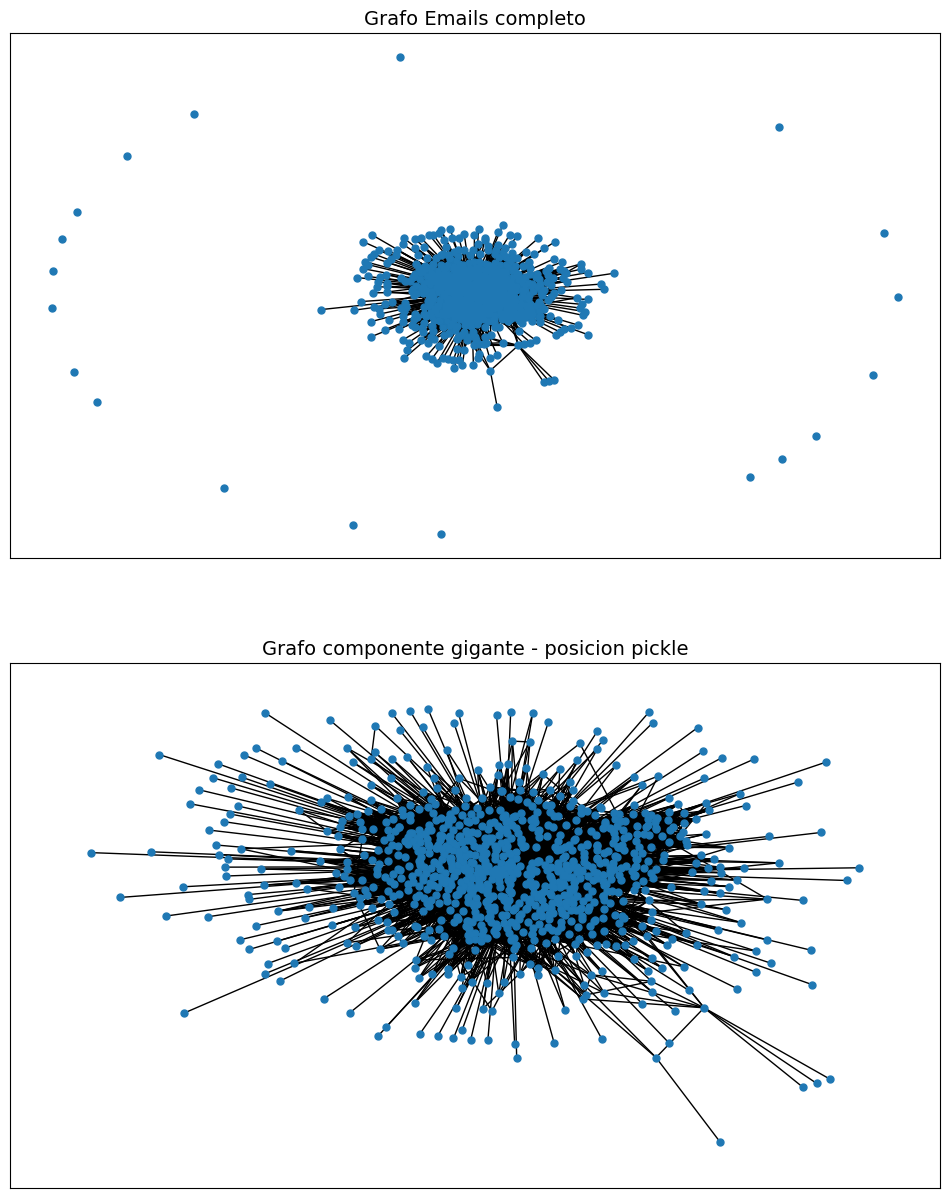

In [23]:
G_per = fb.copy()
G_obs = G.copy()


plt.figure(figsize=(12, 15))

plt.subplot(211)
nx.draw_networkx_nodes(G_obs, pos=pos, node_size=25)
edge_weights_per = nx.get_edge_attributes(G_per, "weight")
# edgeWitdh_per = np.array(list(edge_weights_per.values()))
nx.draw_networkx_edges(G_obs, pos=pos, edgelist=G_per.edges())
plt.title('Grafo Emails completo', fontsize=14)

plt.subplot(212)
nx.draw_networkx_nodes(G_per, pos=pos_email, node_size=25)
# edge_weights_obs = nx.get_edge_attributes(G_obs, "weight")
# edgeWidth_obs = np.array(list(edge_weights_obs.values()))
# edgeWidth_obs = edgeWidth_obs / np.max(edgeWidth_obs)
nx.draw_networkx_edges(G_per, pos=pos_email, edgelist=G_per.edges())
plt.title('Grafo componente gigante - posicion pickle', fontsize=14)

plt.show()

## Medidas de centralidad
Es posible calcular las medias de centralidad que vimos en lcase (ademas de la centralidad de grado):

- Grado: nx.degree_centrality

- Intermediación: nx.betweenness_centrality

- Cercanía: nx.closeness_centrality

- Centralidad de autovectores: nx.eigenvector_centrality



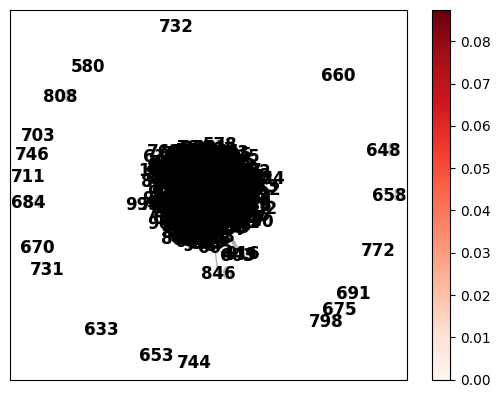

In [30]:
layout = pos

# GRAFIQUEMOS LA CENTRALIDAD DE INTERMEDIACION  DEL GRAFO OBSERVADO
centrality = nx.betweenness_centrality(G_obs)
values = [v for n,v in centrality.items()]
#  Normalizar valores para usarlos como tamaño de nodos
node_size = [5000 * centrality[n] for n in G_obs.nodes()]

h = nx.draw_networkx_nodes(G_obs, layout, node_size=node_size, node_color = values,cmap=plt.cm.Reds)
nx.draw_networkx_labels(G_obs, layout,font_weight='bold', font_color='black')
# edge_weights_obs = nx.get_edge_attributes(G_obs,)
# edgeWidth_obs = np.array(list(edge_weights_obs.values()))
# edgeWidth_obs = edgeWidth_obs / np.max(edgeWidth_obs)
nx.draw_networkx_edges(G_obs, layout, alpha=0.3)# edgelist=G_obs.edges()) #, width=edgeWidth_obs)
nx.draw_networkx_labels(G_obs, layout, alpha=0.3)
plt.colorbar(h)

plt.show()

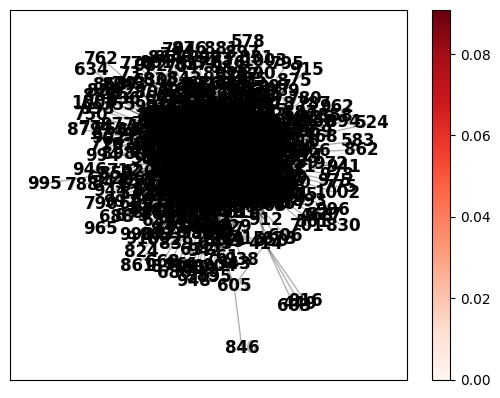

In [31]:
layout = pos

# GRAFIQUEMOS LA CENTRALIDAD DE INTERMEDIACION  DEL GRAFO OBSERVADO
centrality = nx.betweenness_centrality(G_per)
values = [v for n,v in centrality.items()]
#  Normalizar valores para usarlos como tamaño de nodos
node_size = [5000 * centrality[n] for n in G_per.nodes()]

h = nx.draw_networkx_nodes(G_per, layout, node_size=node_size, node_color = values,cmap=plt.cm.Reds)
nx.draw_networkx_labels(G_per, layout,font_weight='bold', font_color='black')
# edge_weights_obs = nx.get_edge_attributes(G_obs,)
# edgeWidth_obs = np.array(list(edge_weights_obs.values()))
# edgeWidth_obs = edgeWidth_obs / np.max(edgeWidth_obs)
nx.draw_networkx_edges(G_per, layout, alpha=0.3)# edgelist=G_obs.edges()) #, width=edgeWidth_obs)
nx.draw_networkx_labels(G_per, layout, alpha=0.3)
plt.colorbar(h)

plt.show()

## comunidades

In [32]:
modulos = nx.community.girvan_newman(G_obs)
modularidad = [] # ESTE EL EL INDICE DE MODULARIDAD (Q) QUE QUEREMOS OPTIMIZAR
mod_max = -999
for communities in modulos:
    n_modularidad = nx.community.modularity(G_obs, tuple(sorted(c) for c in communities)) # CALCULAMOS Q PARA CADA ITERACION
    modularidad.append(n_modularidad)
    if n_modularidad > mod_max: # ME GUARDO LA MAXIMA MODULARIDAD ENCONTRADA, Y LA PARTICIÓN DE COMUNIDADES CORRESPONDIENTE
      mod_max = n_modularidad
      com_max = tuple(sorted(c) for c in communities)

k = np.argmax(modularidad)
print('La modularidad de la partición óptima es:', mod_max)
print('La partición óptima tiene ',len(com_max), ' comunidades')
print('La partición óptima es:', com_max)

KeyboardInterrupt: 

¿Cómo cambia la modularidad Q a medida que vamos haciendo cortes en en el dendrograma?

In [ ]:
plt.plot(modularidad)
plt.xlabel('Iteración')
plt.ylabel('Modularidad (Q)')

plt.show()

Vamos a visualizar las comunidades encontradas

In [ ]:
values = [v for n, v in partition_set_to_dict(com_max).items()] # uso como label (color) la comunidad a la que pertenece cada nodo

plt.figure()
nx.draw_networkx_nodes(G_obs, layout, node_size=300, node_color=values, cmap=plt.cm.tab10)
nx.draw_networkx_labels(G_obs, layout,font_weight='bold', font_color='white')
edge_weights_obs = nx.get_edge_attributes(G_obs, "weight")
edgeWidth_obs = np.array(list(edge_weights_obs.values()))
edgeWidth_obs = edgeWidth_obs / np.max(edgeWidth_obs)
nx.draw_networkx_edges(G_obs, layout, edgelist=G_obs.edges(), width=edgeWidth_obs)

plt.show()